# Hole Similarity Research — v1

This notebook explores **how golf holes compare to each other**, using features
engineered from the pipeline's normalized 3D point clouds (30 courses, 540 holes).

### What the data represents
Each hole was sampled into a dense labeled point cloud (fairway / green / tee /
bunker / water / trees / cartpath / sand / rough). Those points were aggregated
into **one feature row per hole** (`hole_features.parquet`, 540 × ~90).

### The tee-relative coordinate system
Every hole is re-expressed so it is directly comparable to every other hole:
- the **tee is the origin** `(0, 0, 0)`,
- the **green lies along `+Y`** (downrange distance from the tee),
- **`x < 0` is left, `x > 0` is right** of the tee→green line,
- **`z` is elevation relative to the tee** (`z_rel = elevation − tee_elevation`).

So two holes being *close in feature space* means they **play** alike — similar
length, shot shape, hazard pressure (left vs right), and green defense —
regardless of which course they belong to.

### Reading `rough_pct`
Points cover the whole ~200 m-wide hole **corridor** (a 100 m buffer either side
of the centerline). Most of that area is background, so **`rough_pct` is usually
the largest label** and should be read as *"corridor area not covered by another
feature"*, not as *"penal rough"*. Hazard percentages (`bunker/water/trees`) are
the more discriminating signals.

### This is v1
Features are **hand-engineered** and similarity is **Euclidean distance in
standardized feature space**. It's a sensible first approximation for finding
comparable holes — not ground truth. Limitations are listed at the end.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')  # so `import pipeline` works from notebooks/
from pipeline.modeling.similarity import (
    feature_columns, feature_summary, build_feature_matrix,
    run_pca, cluster_kmeans, nearest_neighbor_table, similar_holes,
)

INDEX = Path('..') / 'courses' / '_index'
feat = pd.read_parquet(INDEX / 'hole_features.parquet')
clusters = pd.read_parquet(INDEX / 'hole_clusters.parquet')
examples = pd.read_csv(INDEX / 'hole_similarity_examples.csv')

# Standardized feature matrix (identifiers excluded, NaNs median-imputed).
cols = feature_columns(feat)
X, imputer, scaler = build_feature_matrix(feat, cols)
m = feat.merge(clusters[['hole_id','kmeans_cluster','agg_cluster','pca_1','pca_2']], on='hole_id')
print(f'{len(feat)} holes | {feat["course_slug"].nunique()} courses | {len(cols)} model features')

540 holes | 30 courses | 86 model features


## 1. Data overview

In [2]:
print('Holes:', len(feat), '| Courses:', feat['course_slug'].nunique())
display(feat['par'].value_counts().sort_index().rename('holes').to_frame())
feat[['hole_length_m','fairway_pct','rough_pct','bunker_pct','water_pct',
      'trees_pct','dogleg_score','tee_to_green_elevation_change']].describe().round(3)

Holes: 540 | Courses: 30


,holes
par,
3,111
4,308
5,121


,hole_length_m,fairway_pct,rough_pct,bunker_pct,water_pct,trees_pct,dogleg_score,tee_to_green_elevation_change
count,540.000,540.000,540.000,540.000,540.000,540.000,478.000,540.000
mean,368.760,0.056,0.831,0.008,0.047,0.043,0.121,-1.185
std,114.469,0.034,0.128,0.010,0.079,0.095,0.172,6.415
min,69.740,0.000,0.314,0.000,0.000,0.000,0.006,-35.540
25%,320.293,0.039,0.767,0.003,0.000,0.000,0.048,-3.186
50%,395.518,0.054,0.878,0.005,0.010,0.000,0.086,-0.486
75%,446.063,0.071,0.921,0.009,0.061,0.025,0.139,1.002
max,595.933,0.234,1.000,0.104,0.492,0.572,2.355,21.862


`rough_pct` dominating the mean is expected (corridor background). Hazard
columns are small but are what separate holes strategically.

## 2. Validation

Engineered features are intentionally `NaN` when undefined for a hole (a par-3
has no drive zone). They are **median-imputed** before modeling — but it's worth
seeing *where* the gaps are.

In [3]:
fs = feature_summary(feat, cols)
print('Features with the most missing values (median-imputed before modeling):')
display(fs.head(12))

Features with the most missing values (median-imputed before modeling):


,column,dtype,n_missing,pct_missing
0,fairway_centerline_shift,float64,77,0.1426
1,fairway_width_drive_zone,float64,69,0.1278
2,dogleg_score,float64,62,0.1148
3,fairway_width_approach_zone,float64,50,0.0926
4,green_relative_elevation,float64,21,0.0389
5,drive_bunker_right_pct,float64,2,0.0037
6,drive_zone_trees_pct,float64,2,0.0037
7,drive_zone_sand_pct,float64,2,0.0037
8,drive_bunker_left_pct,float64,2,0.0037
9,drive_water_left_pct,float64,2,0.0037


In [4]:
missing_dogleg = feat[feat['dogleg_score'].isna()][['hole_id','par','hole_length_m']]
print(f'{len(missing_dogleg)} holes missing dogleg_score (par-3s / sparse fairway):')
display(missing_dogleg.sort_values('hole_length_m').head(10))

62 holes missing dogleg_score (par-3s / sparse fairway):


,hole_id,par,hole_length_m
393,tpc_deere_run__16,3,69.740
56,detroit_golf_club__03,3,135.395
120,harbour_town_golf_links__13,3,137.183
104,east_lake_golf_club__15,3,143.893
264,renaissance_club__13,3,146.338
259,renaissance_club__08,3,146.726
222,pga_west_stadium_course__07,3,147.977
294,royal_birkdale_golf_club__07,3,157.474
299,royal_birkdale_golf_club__12,3,169.962
151,la_quinta_country_club__08,3,172.694


Most missing `dogleg_score` / drive-zone widths are par-3s — correct behavior, not data loss.

## 3. PCA — how much structure is in 2D?

The cluster plots below use the first two principal components. PCA is only a
**2D projection** of an ~86-dim space, so it understates real separation; treat
it as a map, not the territory.

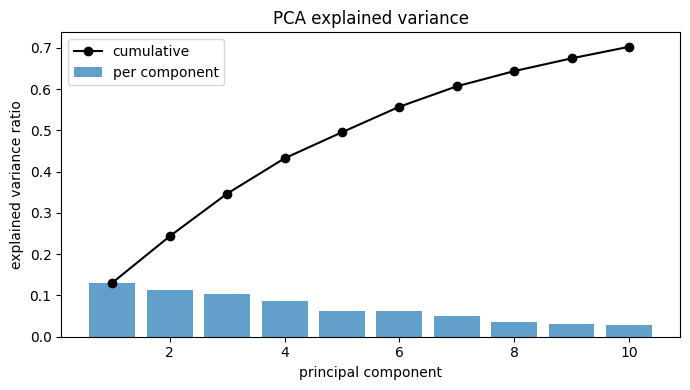

PC1+PC2 explain 24.3% of total variance


In [5]:
_, pca10 = run_pca(X, n_components=10)
evr = pca10.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(evr) + 1), evr, alpha=0.7, label='per component')
ax.plot(range(1, len(evr) + 1), np.cumsum(evr), 'o-', color='black', label='cumulative')
ax.set_xlabel('principal component'); ax.set_ylabel('explained variance ratio')
ax.set_title('PCA explained variance'); ax.legend(); plt.tight_layout(); plt.show()
print('PC1+PC2 explain {:.1%} of total variance'.format(evr[:2].sum()))

## 4. Clusters and profiles

In [6]:
def cluster_profile(m, col='kmeans_cluster'):
    g = m.groupby(col)
    return pd.DataFrame({
        'size': g.size(),
        'mean_par': g['par'].mean(),
        'mean_len': g['hole_length_m'].mean(),
        'fairway': g['fairway_pct'].mean(),
        'rough': g['rough_pct'].mean(),
        'trees': g['trees_pct'].mean(),
        'water': g['water_pct'].mean(),
        'bunker': g['bunker_pct'].mean(),
        'dogleg': g['dogleg_score'].mean(),
    })

prof = cluster_profile(m)
prof.round(3)

,size,mean_par,mean_len,fairway,rough,trees,water,bunker,dogleg
kmeans_cluster,,,,,,,,,
0,244,4.287,422.248,0.062,0.874,0.018,0.028,0.007,0.108
1,44,3.932,350.349,0.083,0.566,0.308,0.023,0.008,0.181
2,91,3.077,186.169,0.016,0.903,0.022,0.035,0.006,0.067
3,62,4.161,379.848,0.058,0.691,0.014,0.215,0.006,0.201
4,34,4.118,388.703,0.063,0.894,0.020,0.007,0.007,0.099
5,11,4.091,405.264,0.051,0.828,0.000,0.055,0.056,0.151
6,3,4.333,451.100,0.059,0.885,0.000,0.005,0.008,0.164
7,51,4.216,415.052,0.067,0.847,0.039,0.009,0.008,0.105


**Cluster sizes & stability.** Cluster sizes vary widely. Very small clusters
(here the smallest has ~3 holes) should be interpreted as **outlier-style groups
rather than stable design categories**. We keep `k=8` for now; the tiny clusters
mostly flag unusual one-off holes.

### Suggested cluster names
A light heuristic labels each cluster from its **median-relative** profile: a base
type from par/length, plus the single most-elevated hazard (or `dogleg` /
`open_low_hazard`). **These are heuristic discussion labels, not an official
taxonomy** — they exist only to make the clusters easier to talk about.

In [7]:
def name_clusters(prof):
    med = prof.median(numeric_only=True)
    haz_map = {'tree_lined': 'trees', 'water_heavy': 'water', 'bunker_heavy': 'bunker'}
    names = {}
    for cid, r in prof.iterrows():
        if r['mean_par'] < 3.5:
            base = 'short_par_3'
        elif r['mean_par'] >= 4.6:
            base = 'long_par_5'
        elif r['mean_len'] >= med['mean_len']:
            base = 'long_standard_par_4'
        else:
            base = 'standard_par_4'
        scored = {lab: (r[c] / med[c] if med[c] > 0 else 0.0) for lab, c in haz_map.items()}
        top_lab, top_ratio = max(scored.items(), key=lambda kv: kv[1])
        if top_ratio >= 1.3:
            mod = top_lab
        elif med['dogleg'] > 0 and r['dogleg'] >= 1.3 * med['dogleg']:
            mod = 'dogleg'
        else:
            mod = 'open_low_hazard'
        names[cid] = f'{base}__{mod}'
    return names

cluster_names = name_clusters(prof)
named = prof.copy()
named.insert(0, 'suggested_name', [cluster_names[c] for c in named.index])
named.round(3)

,suggested_name,size,mean_par,mean_len,fairway,rough,trees,water,bunker,dogleg
kmeans_cluster,,,,,,,,,,
0,long_standard_par_4__open_low_hazard,244,4.287,422.248,0.062,0.874,0.018,0.028,0.007,0.108
1,standard_par_4__tree_lined,44,3.932,350.349,0.083,0.566,0.308,0.023,0.008,0.181
2,short_par_3__water_heavy,91,3.077,186.169,0.016,0.903,0.022,0.035,0.006,0.067
3,standard_par_4__water_heavy,62,4.161,379.848,0.058,0.691,0.014,0.215,0.006,0.201
4,standard_par_4__open_low_hazard,34,4.118,388.703,0.063,0.894,0.020,0.007,0.007,0.099
5,long_standard_par_4__bunker_heavy,11,4.091,405.264,0.051,0.828,0.000,0.055,0.056,0.151
6,long_standard_par_4__open_low_hazard,3,4.333,451.100,0.059,0.885,0.000,0.005,0.008,0.164
7,long_standard_par_4__tree_lined,51,4.216,415.052,0.067,0.847,0.039,0.009,0.008,0.105


In [8]:
print('Par distribution by cluster:')
display(pd.crosstab(m['kmeans_cluster'], m['par']))
print('Course spread by cluster (are clusters dominated by one course?):')
display(m.groupby('kmeans_cluster')['course_slug'].agg(
    distinct_courses='nunique',
    top_course=lambda s: s.value_counts().index[0],
    top_course_n=lambda s: int(s.value_counts().iloc[0])))

Par distribution by cluster:


par,3,4,5
kmeans_cluster,,,
0,0,174,70
1,11,25,8
2,84,7,0
3,9,34,19
4,3,24,7
5,0,10,1
6,0,2,1
7,4,32,15


Course spread by cluster (are clusters dominated by one course?):


,distinct_courses,top_course,top_course_n
kmeans_cluster,,,
0,30,detroit_golf_club,17
1,10,augusta_national,16
2,27,harbour_town_golf_links,6
3,17,trump_national_doral_blue_monster,10
4,11,riviera_country_club,8
5,5,harbour_town_golf_links,5
6,2,bay_hill_club_and_lodge,2
7,14,pebble_beach_golf_links,7


In [9]:
key_feats = ['drive_zone_fairway_pct','approach_zone_fairway_pct',
             'green_complex_bunker_pct','green_complex_water_pct',
             'fairway_width_drive_zone','z_range']
print('Mean strategic features by cluster:')
m.groupby('kmeans_cluster')[key_feats].mean().round(3)

Mean strategic features by cluster:


,drive_zone_fairway_pct,approach_zone_fairway_pct,green_complex_bunker_pct,green_complex_water_pct,fairway_width_drive_zone,z_range
kmeans_cluster,,,,,,
0,0.134,0.109,0.015,0.025,36.121,11.713
1,0.125,0.136,0.017,0.025,41.156,23.824
2,0.015,0.022,0.015,0.046,26.915,13.244
3,0.132,0.107,0.012,0.288,48.679,8.915
4,0.145,0.128,0.019,0.003,41.344,46.824
5,0.132,0.102,0.070,0.108,46.901,10.147
6,0.111,0.068,0.004,0.000,27.612,8.022
7,0.142,0.117,0.020,0.018,41.133,32.951


## 5. Visualizations

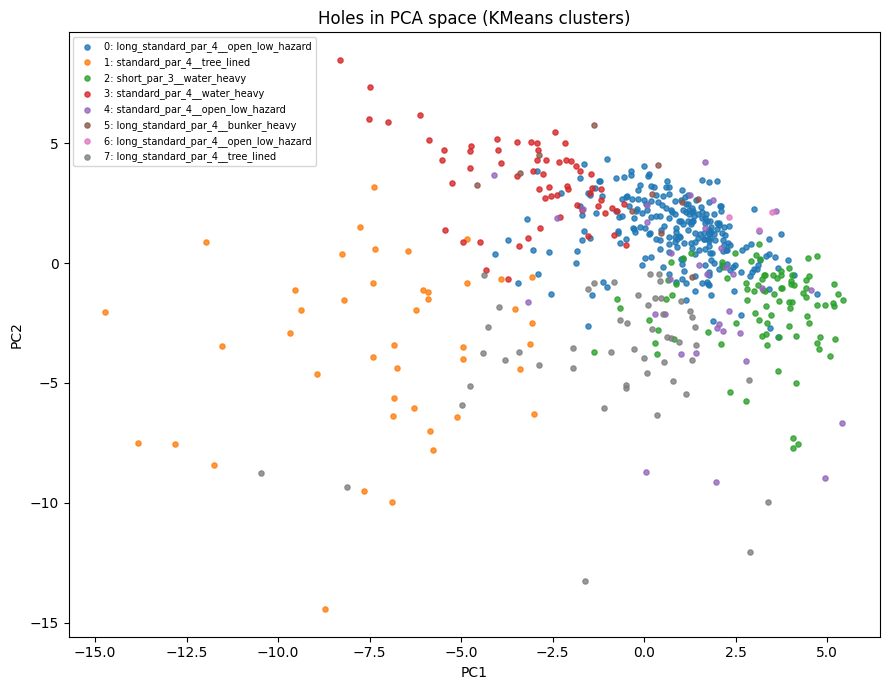

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
for cid, g in m.groupby('kmeans_cluster'):
    ax.scatter(g['pca_1'], g['pca_2'], s=14, alpha=0.8, label=f'{cid}: {cluster_names[cid]}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Holes in PCA space (KMeans clusters)')
ax.legend(fontsize=7, loc='best'); plt.tight_layout(); plt.show()

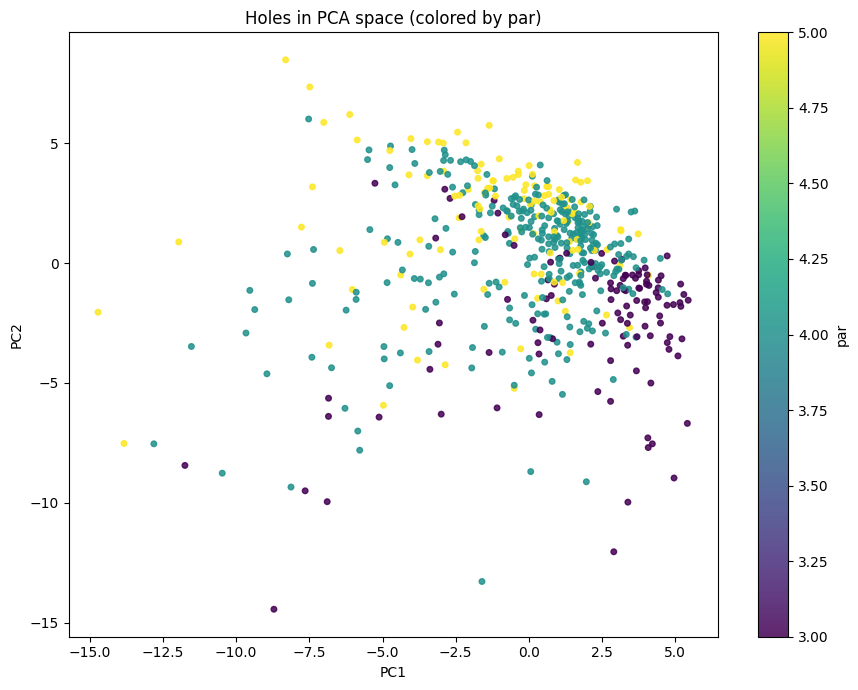

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(m['pca_1'], m['pca_2'], c=m['par'], cmap='viridis', s=16, alpha=0.85)
plt.colorbar(sc, label='par')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Holes in PCA space (colored by par)'); plt.tight_layout(); plt.show()

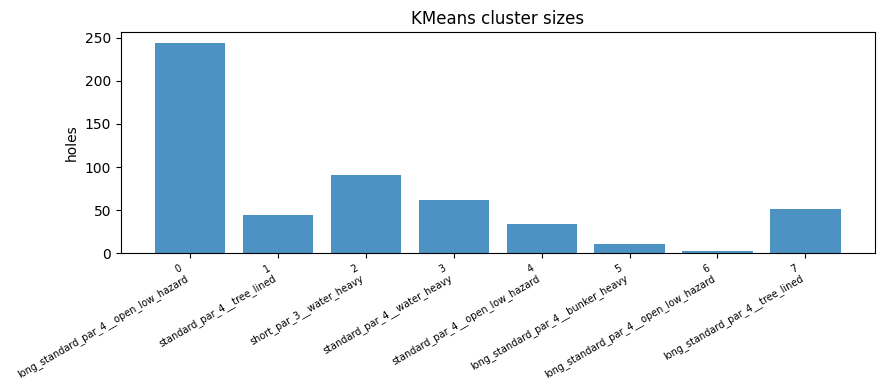

In [12]:
sizes = prof['size'].sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([f'{c}\n{cluster_names[c]}' for c in sizes.index], sizes.values, alpha=0.8)
ax.set_ylabel('holes'); ax.set_title('KMeans cluster sizes')
plt.xticks(rotation=30, ha='right', fontsize=7); plt.tight_layout(); plt.show()

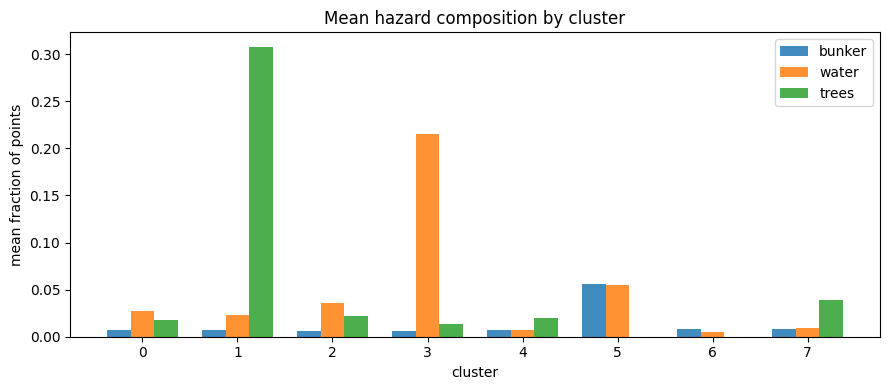

In [13]:
haz = prof[['bunker', 'water', 'trees']]
xpos = np.arange(len(haz)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 4))
for i, c in enumerate(['bunker', 'water', 'trees']):
    ax.bar(xpos + (i - 1) * w, haz[c].values, width=w, label=c, alpha=0.85)
ax.set_xticks(xpos); ax.set_xticklabels(haz.index)
ax.set_ylabel('mean fraction of points'); ax.set_xlabel('cluster')
ax.set_title('Mean hazard composition by cluster'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Find similar holes

`show_similar(hole_id, n, exclude_same_course, same_par)` recomputes neighbors
live from the feature matrix, so it supports cross-course-only and same-par
lookups (and both together). The precomputed CSV is the unrestricted view.

**A note on unrestricted matching.** Plain nearest-neighbor search compares
strategic shape, hazard pressure, and elevation — it does **not** know about par.
So an unrestricted match can legitimately pair a **par 4 with a par 5** when they
play similarly. That isn't wrong, but for a clean presentation `same_par=True`
keeps comparisons apples-to-apples. The **main demo** below uses cross-course
**and** same-par; an unrestricted **diagnostic** follows.

In [14]:
def show_similar(hole_id, n=10, exclude_same_course=False, same_par=False):
    out = similar_holes(feat, X, hole_id, k=n,
                        exclude_same_course=exclude_same_course, same_par=same_par)
    return out[['rank','similar_hole_id','similar_course_slug',
                'similar_hole_number','distance']].reset_index(drop=True)

COMPARE_COLS = ['hole_length_m','par','fairway_pct','rough_pct','bunker_pct',
    'water_pct','trees_pct','dogleg_score','fairway_width_drive_zone',
    'fairway_width_approach_zone','green_complex_bunker_pct',
    'green_complex_water_pct','tee_to_green_elevation_change']

def compare_holes(query_hole_id, match_hole_id):
    sub = (feat[feat['hole_id'].isin([query_hole_id, match_hole_id])]
           .set_index('hole_id')[COMPARE_COLS].T)
    sub = sub[[query_hole_id, match_hole_id]]
    sub['abs_diff'] = (sub[query_hole_id] - sub[match_hole_id]).abs()
    return sub.round(3)

### Same-course bias check

In [15]:
nn10 = nearest_neighbor_table(feat, X, k=10)
same_frac = (nn10['query_course_slug'] == nn10['similar_course_slug']).mean()
print(f"Average share of SAME-course holes in each hole's top-10 neighbors: {same_frac:.1%}")
print('High share => similarity leans on within-course style. Use '
      'exclude_same_course=True for genuinely cross-course matches.')

Average share of SAME-course holes in each hole's top-10 neighbors: 18.3%
High share => similarity leans on within-course style. Use exclude_same_course=True for genuinely cross-course matches.


### Main demo — cross-course, same-par

In [16]:
SAMPLE = 'augusta_national__01'
print(f'Most similar to {SAMPLE} (cross-course AND same par):')
show_similar(SAMPLE, 5, exclude_same_course=True, same_par=True)

Most similar to augusta_national__01 (cross-course AND same par):


,rank,similar_hole_id,similar_course_slug,similar_hole_number,distance
0,1,tpc_deere_run__13,tpc_deere_run,13,12.034133
1,2,tpc_deere_run__11,tpc_deere_run,11,12.152429
2,3,harbour_town_golf_links__10,harbour_town_golf_links,10,12.199949
3,4,detroit_golf_club__07,detroit_golf_club,7,12.398848
4,5,tpc_deere_run__09,tpc_deere_run,9,12.491035


In [17]:
match = show_similar(SAMPLE, 1, exclude_same_course=True, same_par=True)['similar_hole_id'].iloc[0]
print(f'{SAMPLE}  vs  {match}  (top cross-course, same-par match)')
compare_holes(SAMPLE, match)

augusta_national__01  vs  tpc_deere_run__13  (top cross-course, same-par match)


hole_id,augusta_national__01,tpc_deere_run__13,abs_diff
hole_length_m,409.416,303.358,106.058
par,4.000,4.000,0.000
fairway_pct,0.234,0.094,0.141
rough_pct,0.547,0.772,0.225
bunker_pct,0.004,0.013,0.009
water_pct,0.000,0.000,0.000
trees_pct,0.203,0.107,0.097
dogleg_score,0.062,0.042,0.020
fairway_width_drive_zone,43.417,35.560,7.857
fairway_width_approach_zone,50.248,40.870,9.378


### Diagnostic — unrestricted matching
Shown for transparency; note it may mix pars.

In [18]:
print('Unrestricted (any course, any par):')
display(show_similar(SAMPLE, 5))
print('Cross-course only (any par):')
display(show_similar(SAMPLE, 5, exclude_same_course=True))

Unrestricted (any course, any par):


,rank,similar_hole_id,similar_course_slug,similar_hole_number,distance
0,1,augusta_national__14,augusta_national,14,8.092740
1,2,augusta_national__03,augusta_national,3,10.165056
2,3,augusta_national__18,augusta_national,18,11.074746
3,4,augusta_national__08,augusta_national,8,11.358390
4,5,detroit_golf_club__14,detroit_golf_club,14,11.527480


Cross-course only (any par):


,rank,similar_hole_id,similar_course_slug,similar_hole_number,distance
0,1,detroit_golf_club__14,detroit_golf_club,14,11.527480
1,2,tpc_deere_run__10,tpc_deere_run,10,11.804204
2,3,tpc_deere_run__13,tpc_deere_run,13,12.034133
3,4,tpc_deere_run__11,tpc_deere_run,11,12.152429
4,5,harbour_town_golf_links__10,harbour_town_golf_links,10,12.199949


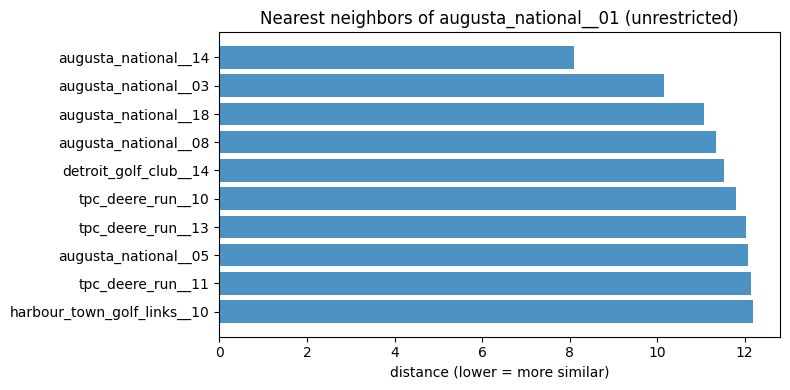

In [19]:
nb = show_similar(SAMPLE, 10)  # unrestricted, for the distance profile
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(nb['similar_hole_id'][::-1], nb['distance'][::-1], alpha=0.8)
ax.set_xlabel('distance (lower = more similar)')
ax.set_title(f'Nearest neighbors of {SAMPLE} (unrestricted)'); plt.tight_layout(); plt.show()

## 7. What the clusters mean (golf interpretation)

Read this next to the **suggested_name** table (section 4):

- **`short_par_3__*`** — short, no real drive zone; defended mostly at the green
  complex. These separate cleanly from everything else.
- **`standard_par_4__*` / `long_standard_par_4__*`** — the bulk of holes; split
  further by their dominant hazard or by dogleg shape.
- **`long_par_5__*`** — longest holes, biggest elevation range, widest fairways.
- **`*__tree_lined`** — parkland corridors (high `trees`); **`*__water_heavy`** —
  forced carries / water in play; **`*__bunker_heavy`** — sandy defense;
  **`*__dogleg`** — bent fairways; **`*__open_low_hazard`** — links/desert-style
  openness.

Because every hole lives in the same tee-relative aligned frame, "similar" here
means "plays similarly," not "looks similar on a scorecard."

## 8. Limitations & recommended next steps

**Limitations (v1):**
- **Background dominance** — `rough_pct` reflects the wide corridor, not penal
  rough; it can wash out subtle differences. Consider hazard-weighted distance.
- **Same-course bias** — holes from one course share style/terrain/OSM-tagging,
  so top neighbors skew same-course (quantified in section 6). Use
  `exclude_same_course=True` for cross-course discovery.
- **Par-agnostic distance** — unrestricted search can match across pars; use
  `same_par=True` for apples-to-apples comparisons.
- **OSM tagging inconsistency** — feature presence depends on how each course was
  mapped (e.g. some courses lack `rough_osm` or `cartpath`).
- **PCA is a 2D projection** — good for a map, not for measuring true distances;
  clustering/NN run on the full standardized space, not on PCA.
- **Engineered, not learned** — these are hand-built features, not a learned
  embedding; they encode our assumptions about what matters.

**Next steps (later):**
- Feature weighting / selection (emphasize hazards, de-emphasize background).
- A cross-course-only similarity export alongside the default.
- UMAP embedding for non-linear structure (optional dependency).
- Zone-emphasis variants (e.g. "approach-similar" vs "off-the-tee-similar").
- Eventually: learned hole embeddings from the raw point clouds.